In [1]:
%matplotlib inline

import tqdm
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import torch_geometric as pyg
import matplotlib.pyplot as plt
import torch.nn.functional as F

from tqdm import tqdm
from sklearn.manifold import TSNE
from torch_sparse import SparseTensor
from torch_geometric.utils import to_networkx
from torch.utils.data import DataLoader, SubsetRandomSampler

from common.utils import Utils
from common.nn_params import NNParams
from common.feed_fwd_nn import FeedFwdNN
from common.graph_conv_nn import GraphConvNN
from common.graph_sage_nn import GraphSageNN
from common.nn_model import NNModel, NNTrainParams
from common.graph_att_nn import GraphAttNN, GraphAttNNParams

In [2]:
dataset = pyg.datasets.Reddit2(
    root="./data"
    , transform=pyg.transforms.Compose(
        [
            pyg.transforms.NormalizeFeatures()
            , pyg.transforms.ToSparseTensor()
        ]
    )
)

In [3]:
N_NEIGHBORS = [20, 15, 10]

train_loader = pyg.loader.NeighborLoader(
    data=dataset._data
    , shuffle=True
    , num_workers=4
    , num_neighbors=N_NEIGHBORS
    , input_nodes=dataset._data.train_mask
    , batch_size=int(dataset._data.train_mask.sum())
)

val_loader = pyg.loader.NeighborLoader(
    data=dataset._data
    , shuffle=False
    , num_workers=4
    , num_neighbors=N_NEIGHBORS
    , input_nodes=dataset._data.val_mask
    , batch_size=int(dataset._data.val_mask.sum())
)

test_loader = pyg.loader.NeighborLoader(
    data=dataset._data
    , shuffle=False
    , num_workers=4
    , num_neighbors=N_NEIGHBORS
    , input_nodes=dataset._data.test_mask
    , batch_size=int(dataset._data.test_mask.sum())
)

print(f"Val Loader Len: {len(val_loader.dataset):,}")
print(f"Test Loader Len: {len(test_loader.dataset):,}")
print(f"Train Loader Len: {len(train_loader.dataset):,}")

/opt/conda/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:50: UserWarning: Using '{self.__class__.__name__}' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn("Using '{self.__class__.__name__}' without a "


Val Loader Len: 23,699
Test Loader Len: 55,334
Train Loader Len: 153,932


In [4]:
net = GraphAttNN(
    params=GraphAttNNParams(
        n_heads=4
        , hidden_dims=[128]
        , dropout_prob=0.25
        , input_dim=dataset.num_features
        , output_dim=dataset.num_classes
    )
)

model = NNModel(net=net)

In [5]:
val_batch = next(iter(val_loader))
val_X, val_Y = net.unpack_batch(val_batch)

test_batch = next(iter(test_loader))
test_X, test_Y = net.unpack_batch(test_batch)

In [6]:
val_X[0].shape

torch.Size([222202, 602])

In [7]:
val_Y_hat = model.predict(X=val_X)

In [8]:
ts = [t for t in range(dataset.num_classes)]
cs = sns.color_palette(n_colors=dataset.num_classes)

df_val_Y_hat_H = pd.DataFrame(val_Y_hat[0].detach().cpu().numpy())
df_val_Y = pd.DataFrame(val_Y.detach().cpu().numpy(), columns=["community"])

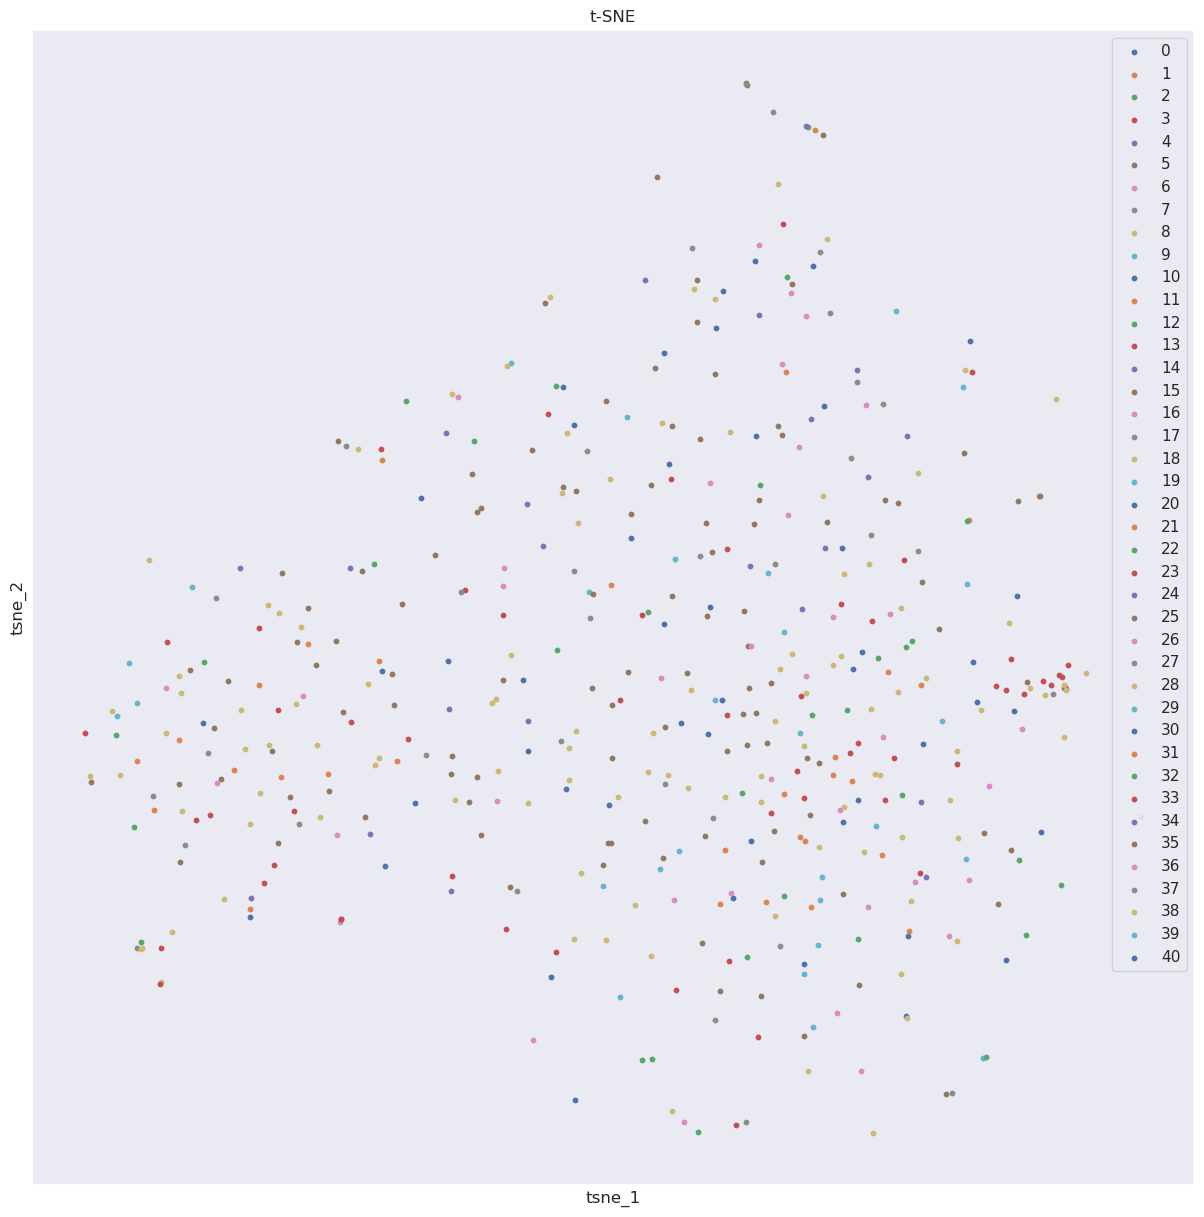

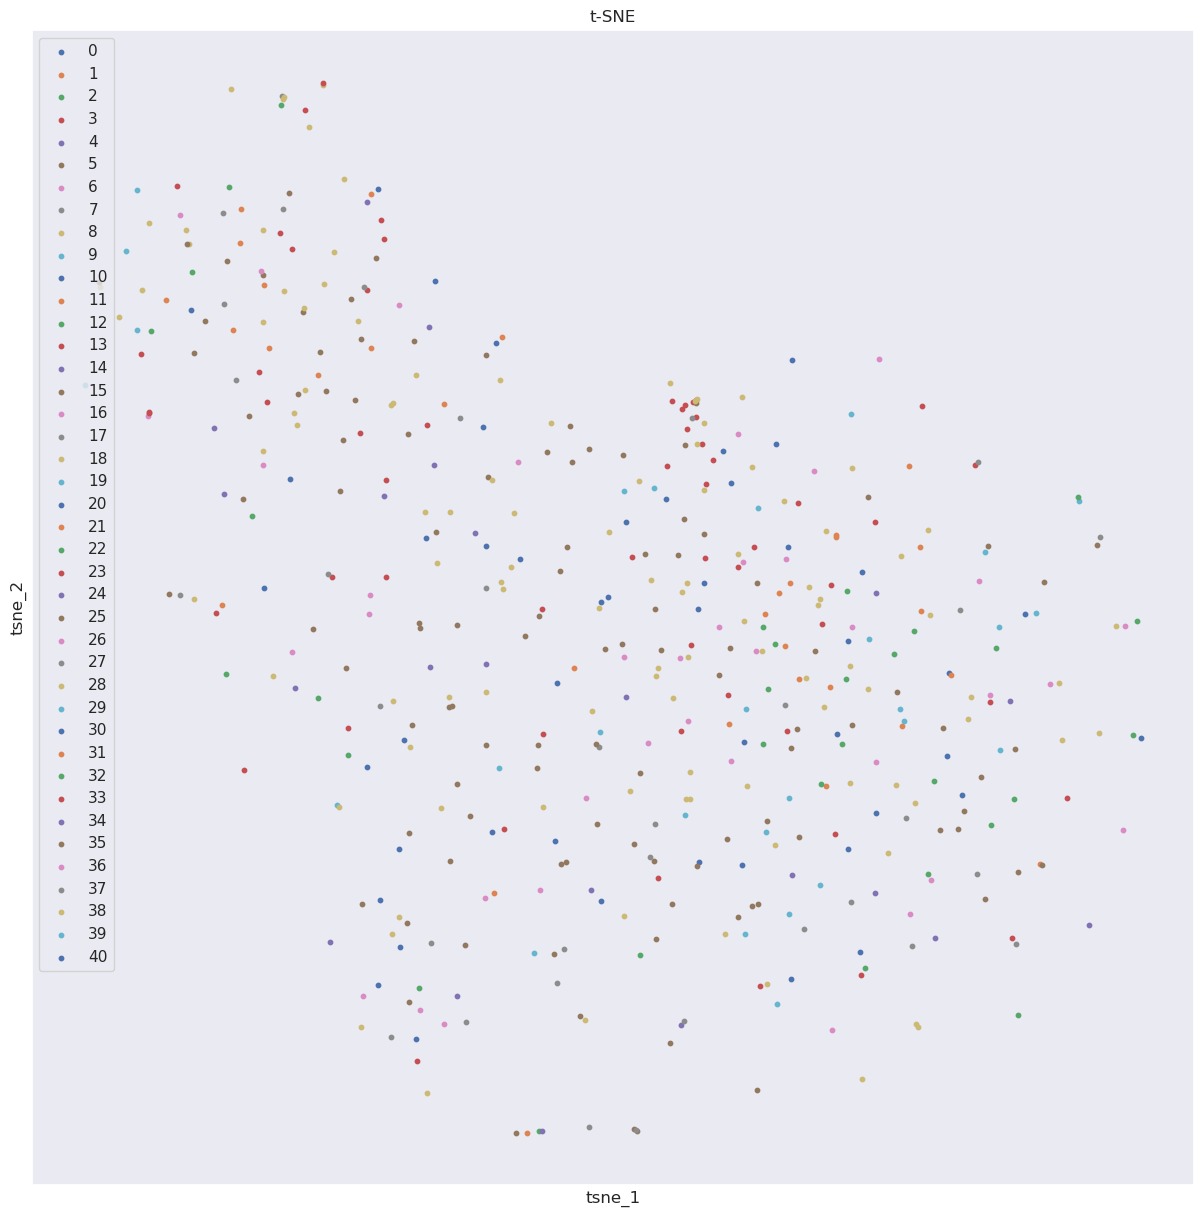

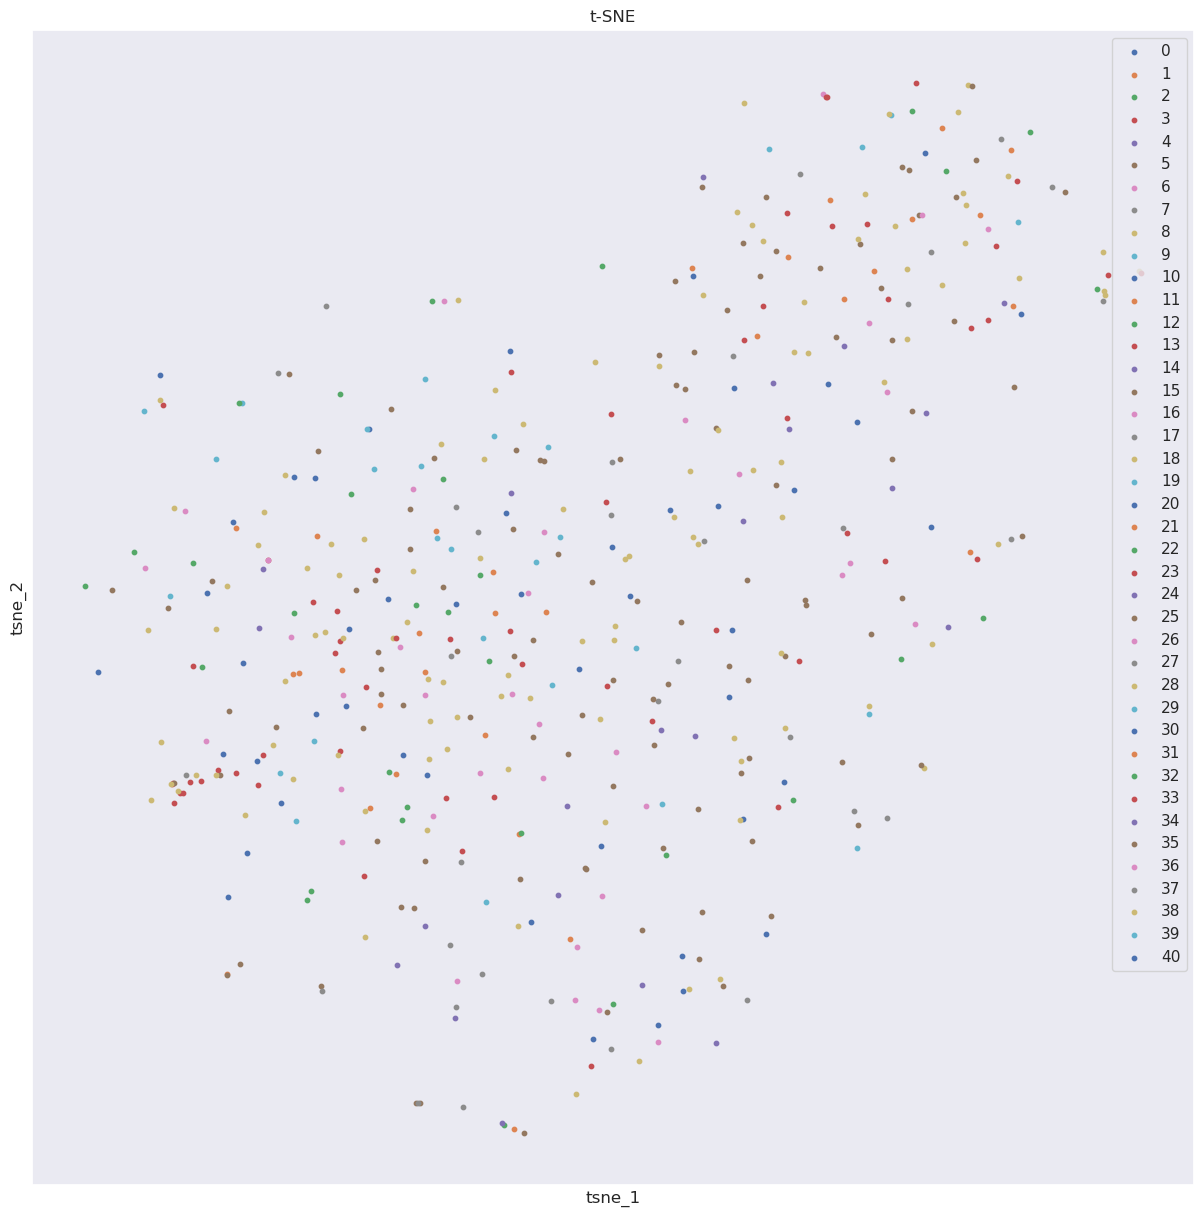

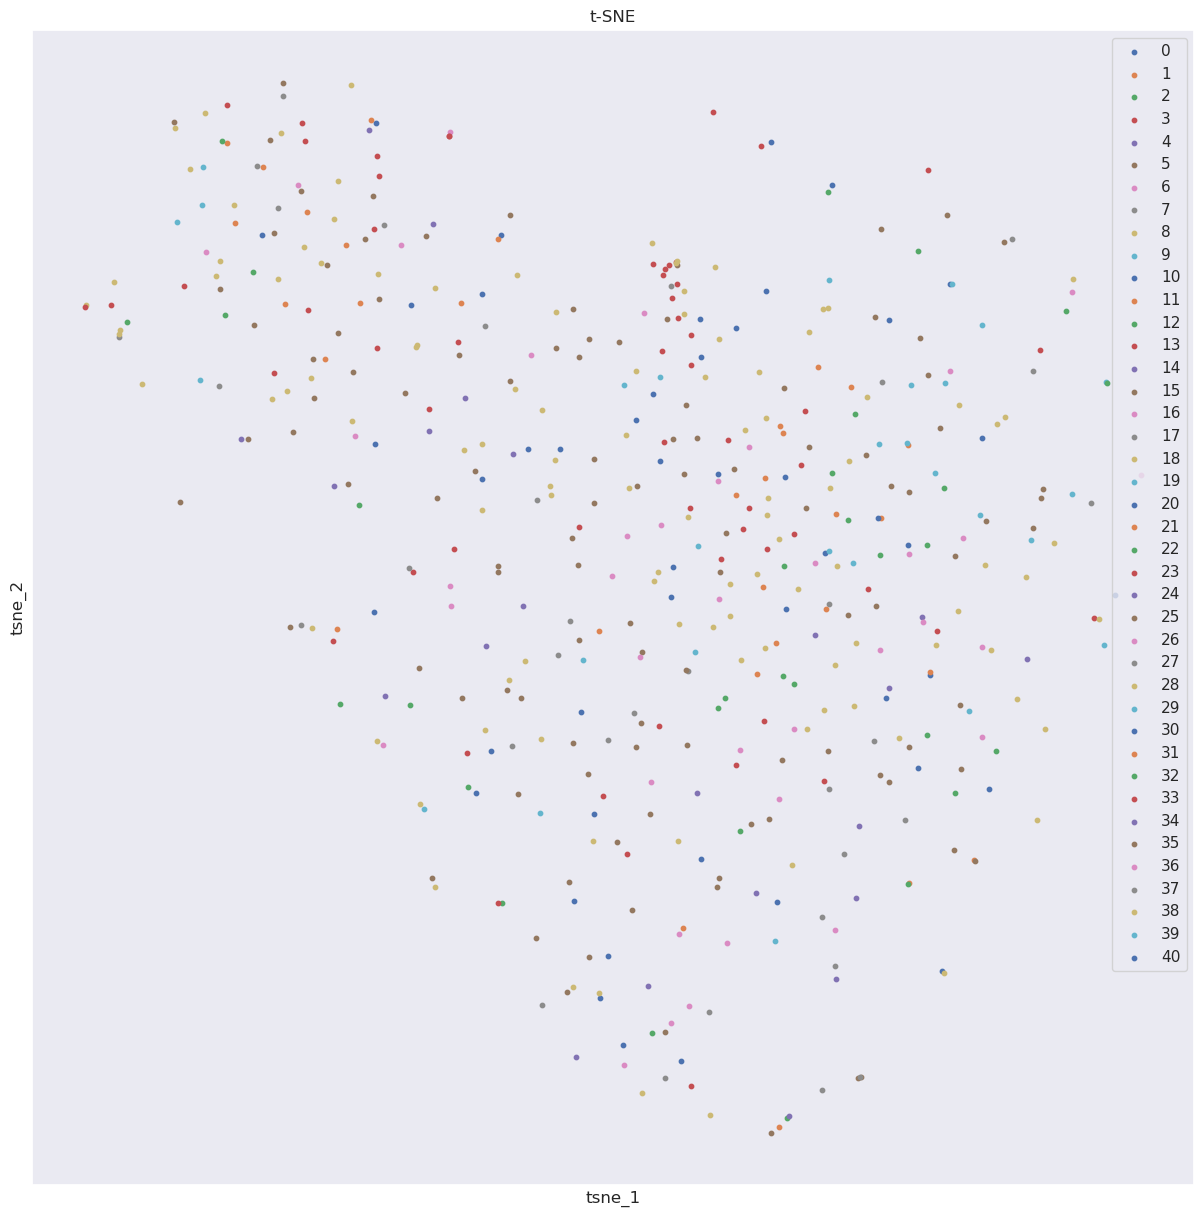

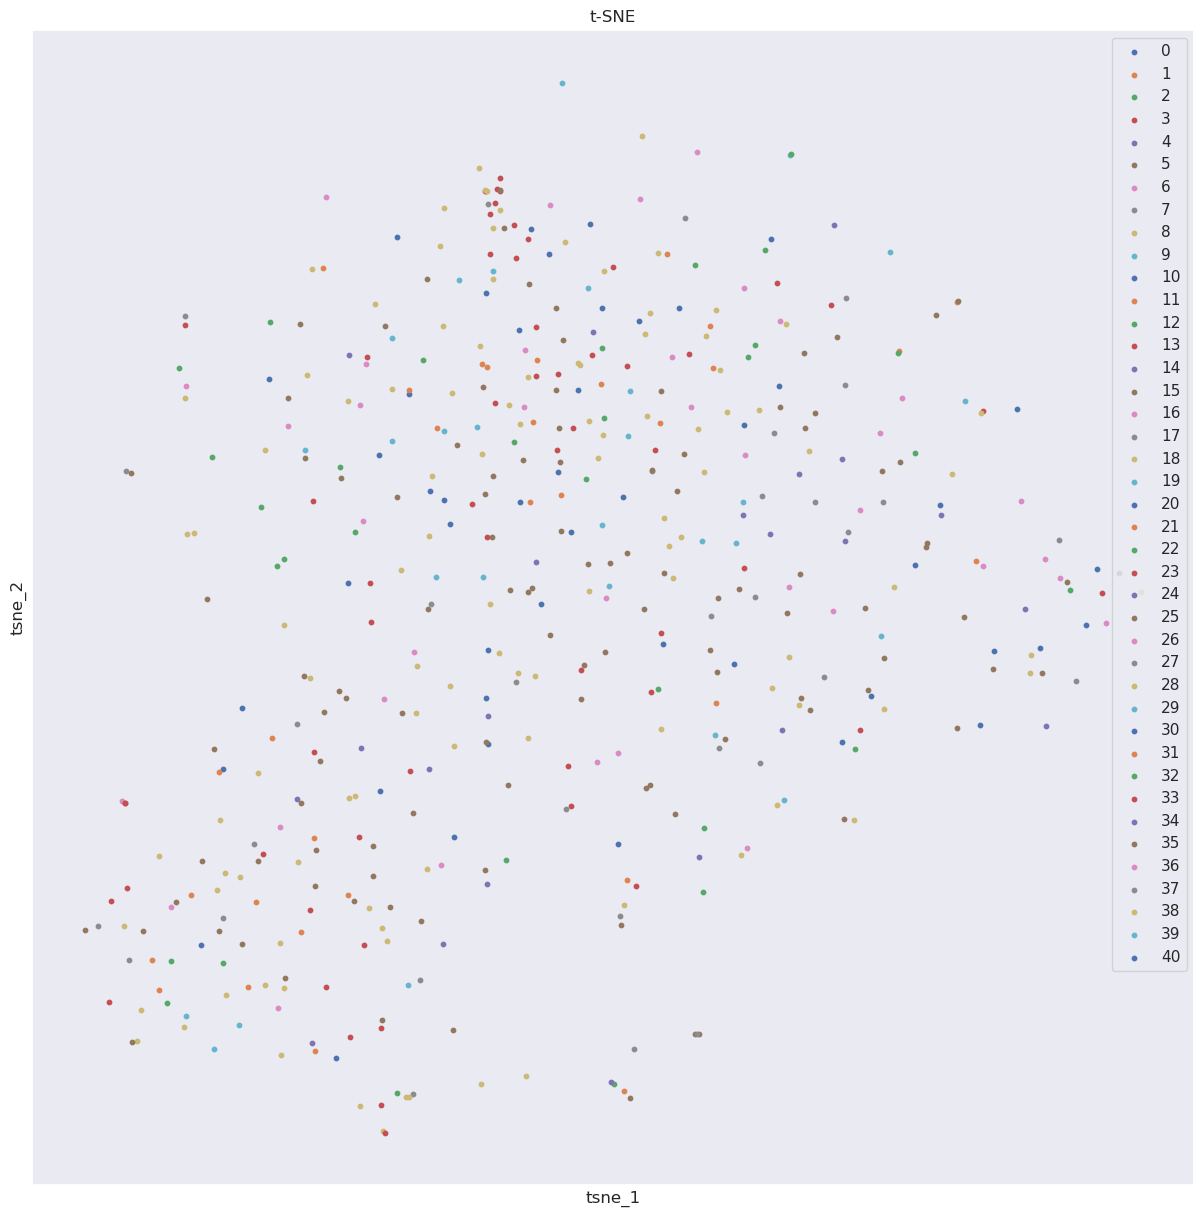

In [9]:
n_sample = 500

Utils.scatter_plot(
    vm=Utils.get_scatter_plot_vm(
        data=pd.concat(
            axis=1
            , objs=[
                pd.DataFrame(
                    data=TSNE(
                        n_components=2
                    ).fit_transform(df_val_Y_hat_H.iloc[:n_sample, :])
                    , columns=["tsne_1", "tsne_2"]
                )
                , df_val_Y.iloc[:n_sample, :]
            ]
        )
        , title="t-SNE"
        , col_xs="tsne_1"
        , col_ys="tsne_2"
        , col_ts="community"
        , colors_ts=cs
        , label_xs="tsne_1"
        , label_ys="tsne_2"
        , uni_ts=ts
        , labels_ts=ts
    )
)

In [ ]:
n_heads = 4
n_epochs = 250
optims = ["adam"]
lrs = [1e-4]
weight_decay = 5e-4

dropout_probs = [0.5]
hidden_dimss = [
    [1024, 512, 256]
]

paramss = [
    NNParams(
        hidden_dims=hidden_dims
        , dropout_prob=dropout_prob
        , input_dim=dataset.num_features
        , output_dim=dataset.num_classes
    )
        for dropout_prob in dropout_probs
        for hidden_dims in hidden_dimss
]

nets = []
# nets += [
#     GraphAttNN(params=params) for params in [
#         GraphAttNNParams(
#             n_heads=n_heads
#             , input_dim=params.input_dim
#             , output_dim=params.output_dim
#             , hidden_dims=params.hidden_dims
#             , dropout_prob=params.dropout_prob
#         )   for params in paramss
#     ]
# ]

nets += [GraphSageNN(params=params) for params in paramss]
nets += [GraphConvNN(params=params) for params in paramss]
nets += [FeedFwdNN(params=params) for params in paramss]

models = [NNModel(device="cpu", net=net) for net in nets]

train_params = [
    train_param
        for train_param in [
            NNTrainParams(
                optim=optim
                , learning_rate=lr
                , n_epochs=n_epochs
                , val_loader=val_loader
                , train_loader=train_loader
                , weight_decay=weight_decay
            )
                for lr in lrs
                for optim in optims 
        ]
]

In [ ]:
trains = {
    train_str: (model, train_idps)
        for model, (train_str, train_idps) in [
            (model, model.train(params=train_param))
                for model in models
                for train_param in train_params
        ]
}

In [ ]:
top_model_names = [
    kvp[0] for kvp in sorted(
        list(trains.items())
        , key=lambda kvp: min(
            kvp[1][1]
            , key=lambda idp: idp.val_error
        ).val_error
    )[:10]
]

In [ ]:
Utils.multi_line_plot(
    x_ticks_inc=10
    , fig_size=(25, 20)
    , y_axis_label="Loss"
    , x_axis_label="Iterations"
    , title=f"Training & Validation Losses"
    , x=[idp.iter_idx for idp in trains[top_model_names[0]][1]]
    , yss_legend=[[f"{loss_type} of {model_name}" for loss_type in ["training", "validation"]] for model_name in top_model_names]
    , yss=[[[model_idp.train_loss for model_idp in trains[model_name][1]], [model_idp.val_loss for model_idp in trains[model_name][1]]] for model_name in top_model_names]
)

In [ ]:
Utils.multi_line_plot(
    x_ticks_inc=5
    , fig_size=(25, 20)
    , y_axis_label="Error"
    , x_axis_label="Iterations"
    , title=f"Training & Validation Errors"
    , x=[idp.iter_idx for idp in trains[top_model_names[0]][1]]
    , yss_legend=[[f"{loss_type} of {model_name}" for loss_type in ["training", "validation"]] for model_name in top_model_names]
    , yss=[[[model_idp.train_error for model_idp in trains[model_name][1]], [model_idp.val_error for model_idp in trains[model_name][1]]] for model_name in top_model_names]
)

In [ ]:
print(f"best model is {top_model_names[0]} which achieves validation error of {min(trains[top_model_names[0]][1], key=lambda idp: idp.val_error).val_error:.4f}")